***Ghibli style image using Ghibli diffusion model by stable diffusion***

**Image-to-Image**

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


model_index.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

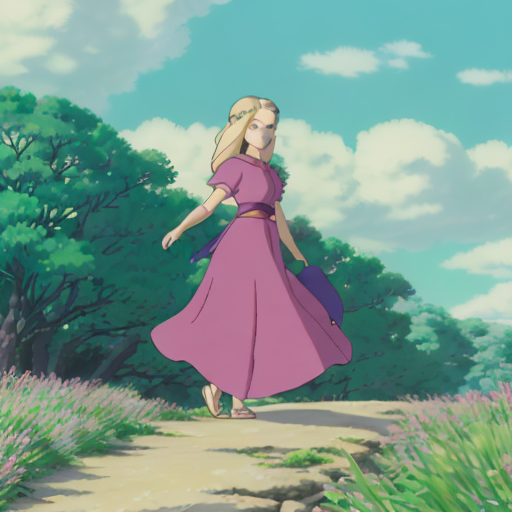

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "nitrosocke/Ghibli-Diffusion"

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# Load model
if device == "cuda":
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    )
else:
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float32
    )

pipe = pipe.to(device)

# Prompt
prompt = "ghibli style magical princess with golden hair, fantasy world, beautiful scenery"

# Generate image
image = pipe(prompt).images[0]

# Save image
image.save("magical_princess.png")

image

In [ ]:
!pip install gradio

In [ ]:
from diffusers import StableDiffusionImg2ImgPipeline, LMSDiscreteScheduler
#The LMSDiscreteScheduler helps manage the "timing" and "steps"during image generation to make sure the process is efficient and produces a high-quality result.
import torch
from PIL import Image
import gradio as gr
import numpy as np

In [ ]:
!pip install random1
import random

ERROR: Could not find a version that satisfies the requirement random1 (from versions: none)
ERROR: No matching distribution found for random1


In [ ]:
def predict(scheduler, prompt, image, strength, guidance_scale):

    pipeline = StableDiffusionImg2ImgPipeline.from_pretrained("nitrosocke/Ghibli-Diffusion")

    if scheduler == "LMS":
      lms = LMSDiscreteScheduler.from_config(pipeline.scheduler.config)
      pipeline.scheduler = lms
      return pipeline(prompt=prompt, image=image.convert("RGB"), strength=strength, guidance_scale=guidance_scale).images[0]
    else:
      return pipeline(prompt=prompt, image=image.convert("RGB"), strength=strength, guidance_scale=guidance_scale).images[0]


In [ ]:
import gradio as gr

# Define the predict function
def predict(image):
    # Add the image processing logic here
    # For now, just return the input image as the output (for demonstration)
    return image

# Create the Gradio interface
gr.Interface(
    predict,  # The function to call when the interface is used
    inputs=gr.Image(type="pil"),  # Input: just an image
    outputs=gr.Image(),  # Output: generated image
    title="Simple Image-to-Image Generation",
).launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://61df73066b37f47e25.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
